# Análisis de características de audio (Spotify Tracks Dataset)

## 0.1. Introducción

El objetivo de este proyecto es analizar qué características de audio influyen en la popularidad de una canción en Spotify.

A partir de este análisis, se desarrollarán modelos de machine learning capaces de predecir la popularidad de una pista y clasificar si una canción puede considerarse un “hit”.

Este problema combina análisis exploratorio, regresión, clasificación e interpretación de modelos.

## 0.2. Descripción del dataset

El dataset utilizado contiene información de pistas de Spotify con características de audio detalladas.

- Número de observaciones: ~114,000 pistas
- Unidad de análisis: 1 fila = 1 pista

El dataset incluye metadatos de pistas (nombre, artista, álbum) y métricas detalladas de características de audio calculadas por los algoritmos de análisis de audio de Spotify.

## 0.3. Características de audio

El dataset contiene las siguientes características de audio clave:

- **Acousticness (acústicamente)**: Medida de confianza de si la pista es acústica (0.0 - 1.0)
- **Danceability (danzabilidad)**: Idoneidad de una pista para bailar (0.0 - 1.0)
- **Energy (energía)**: Intensidad y nivel de actividad (0.0 - 1.0)
- **Instrumentalness (instrumentalidad)**: Probabilidad de que la pista sea instrumental (0.0 - 1.0)
- **Liveness (sonido en vivo)**: Presencia de audiencia en vivo (0.0 - 1.0)
- **Loudness (volumen)**: Volumen general en decibelios (dB)
- **Speechiness (hablabilidad)**: Presencia de palabras habladas (0.0 - 1.0)
- **Tempo**: Velocidad y ritmo en pulsaciones por minuto (BPM)
- **Valence (valencia)**: Positividad musical/alegría (0.0 - 1.0)
- **Popularity (popularidad)**: Puntuación de popularidad de Spotify (0 - 100)

## 0.4. Objetivos del proyecto

1. Analizar la distribución de las características de audio  
2. Estudiar la relación entre estas características y la popularidad  
3. Identificar las variables más influyentes  
4. Construir modelos de regresión para predecir popularidad  
5. Construir modelos de clasificación para identificar canciones exitosas  
6. Interpretar los modelos y extraer conclusiones relevantes  

## 0.5. Estructura del proyecto

El análisis seguirá estas fases:

1. Carga y exploración inicial de datos
2. Limpieza y preparación de datos
3. Análisis Exploratorio de Datos (EDA)
4. Análisis estadístico y correlaciones
5. Visualización de patrones y tendencias
6. Insights y conclusiones

---

# 1. Carga y exploración de datos

## 1.1 Importación de librerías requeridas

Importamos las librerías necesarias para la manipulación y análisis de datos.

In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración básica
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1.2. Carga del dataset

El dataset se carga desde un archivo CSV descargado de Kaggle. El archivo debe colocarse en la carpeta `data/`.

In [184]:
df = pd.read_csv("../data/spotify-tracks.csv")

## 1.3. Exploración inicial de datos

Examinamos las primeras filas del dataset para entender su estructura.

In [185]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


### Dimensiones del dataset e información básica

In [186]:
print(f"Dimensiones del dataset: {df.shape}")
print(f"\nNúmero de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

Dimensiones del dataset: (114000, 20)

Número de filas: 114000
Número de columnas: 20


### Tipos de datos y valores faltantes

In [187]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

In [188]:
df.isnull().sum()

track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Se han detectado únicamente 3 valores nulos en columnas de texto. Al ser un número despreciable frente a los 114.000 registros, se han decidido eliminar directamente sin impacto en el análisis.

In [189]:
df = df.dropna()

### Resumen estadístico

In [190]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113999.000000,1.139990e+05,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,33.238827,2.280312e+05,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034
std,22.304959,1.072961e+05,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623
min,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## 1.4. Análisis de valores duplicados

Verificamos si existen pistas duplicadas en el dataset. En datasets de Spotify es común encontrar la misma canción repetida en distintos géneros o álbumes.

### Detección de duplicados

In [191]:
# Duplicados exactos (todas las columnas)
print(f"Filas duplicadas exactas: {df.duplicated().sum()}")

# Duplicados por track_id (misma canción en distintas filas)
print(f"Duplicados por track_id: {df.duplicated(subset='track_id').sum()}")

# Ejemplo de pistas duplicadas
duplicated_ids = df[df.duplicated(subset='track_id', keep=False)]
print(f"\nPistas con track_id repetido: {duplicated_ids['track_id'].nunique()}")
duplicated_ids.sort_values('track_id').head(10)

Filas duplicadas exactas: 450
Duplicados por track_id: 24259

Pistas con track_id repetido: 16641


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
15028,001APMDOl3qtx1526T11n1,Pink Sweat$;Kirby,New RnB,Better,0,176320,False,0.613,0.471,1,-6.644,0,0.1070,0.31600,0.000001,0.1170,0.406,143.064,4,chill
103211,001APMDOl3qtx1526T11n1,Pink Sweat$;Kirby,New RnB,Better,0,176320,False,0.613,0.471,1,-6.644,0,0.1070,0.31600,0.000001,0.1170,0.406,143.064,4,soul
85578,001YQlnDSduXd5LgBd66gT,Soda Stereo,Soda Stereo (Remastered),El Tiempo Es Dinero - Remasterizado 2007,38,177266,False,0.554,0.921,2,-4.589,1,0.0758,0.01940,0.088100,0.3290,0.700,183.571,1,punk-rock
100420,001YQlnDSduXd5LgBd66gT,Soda Stereo,Soda Stereo (Remastered),El Tiempo Es Dinero - Remasterizado 2007,38,177266,False,0.554,0.921,2,-4.589,1,0.0758,0.01940,0.088100,0.3290,0.700,183.571,1,ska
91801,003vvx7Niy0yvhvHt4a68B,The Killers,Hot Fuss,Mr. Brightside,86,222973,False,0.352,0.911,1,-5.230,1,0.0747,0.00121,0.000000,0.0995,0.236,148.033,4,rock
3257,003vvx7Niy0yvhvHt4a68B,The Killers,Hot Fuss,Mr. Brightside,86,222973,False,0.352,0.911,1,-5.230,1,0.0747,0.00121,0.000000,0.0995,0.236,148.033,4,alternative
2106,003vvx7Niy0yvhvHt4a68B,The Killers,Hot Fuss,Mr. Brightside,86,222973,False,0.352,0.911,1,-5.230,1,0.0747,0.00121,0.000000,0.0995,0.236,148.033,4,alt-rock
33178,004h8smbIoAkUNDJvVKwkG,Ouse;Powfu,Loners Diary,Lovemark,58,219482,True,0.808,0.331,5,-13.457,1,0.0557,0.13100,0.000000,0.2250,0.337,140.035,4,emo
94239,004h8smbIoAkUNDJvVKwkG,Ouse;Powfu,Loners Diary,Lovemark,58,219482,True,0.808,0.331,5,-13.457,1,0.0557,0.13100,0.000000,0.2250,0.337,140.035,4,sad
97533,006rHBBNLJMpQs8fRC2GDe,Calcinha Preta;Gusttavo Lima,CP 25 Anos (Ao Vivo em Aracaju),Agora Estou Sofrendo - Ao Vivo,47,260510,False,0.605,0.678,0,-3.257,1,0.0311,0.64200,0.000000,0.1570,0.439,125.059,4,sertanejo


### Exploración de un caso concreto

In [192]:
# Ver un ejemplo concreto de duplicado
example_id = duplicated_ids['track_id'].value_counts().index[0]
df[df['track_id'] == example_id][['track_id', 'track_name', 'artists', 'album_name', 'track_genre', 'popularity']]

,track_id,track_name,artists,album_name,track_genre,popularity
8315,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,Straight Up (Remastered 2010 / Deluxe Edition),blues,67
19759,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,Straight Up (Remastered 2010 / Deluxe Edition),country,67
34728,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,Straight Up (Remastered 2010 / Deluxe Edition),folk,67
62226,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,Straight Up (Remastered 2010 / Deluxe Edition),j-pop,67
63087,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,Straight Up (Remastered 2010 / Deluxe Edition),j-rock,67
82064,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,Straight Up (Remastered 2010 / Deluxe Edition),power-pop,67
84129,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,Straight Up (Remastered 2010 / Deluxe Edition),psych-rock,67
99727,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,Straight Up (Remastered 2010 / Deluxe Edition),singer-songwriter,67
102732,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,Straight Up (Remastered 2010 / Deluxe Edition),songwriter,67


### Eliminación de valores duplicados

In [193]:
print(f"Filas antes de eliminar duplicados: {df.shape[0]}")
df = df.drop_duplicates(subset='track_id', keep='first')
print(f"Filas después de eliminar duplicados: {df.shape[0]}")

Filas antes de eliminar duplicados: 113999
Filas después de eliminar duplicados: 89740


---

# 2. Análisis exploratorio de datos (EDA)

## 2.1. Distribución de características de audio

Analizamos la distribución de las principales características de audio para entender sus características.

In [194]:
# Seleccionar columnas numéricas para análisis
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Columnas numéricas: {numeric_cols}")

Columnas numéricas: ['popularity', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']


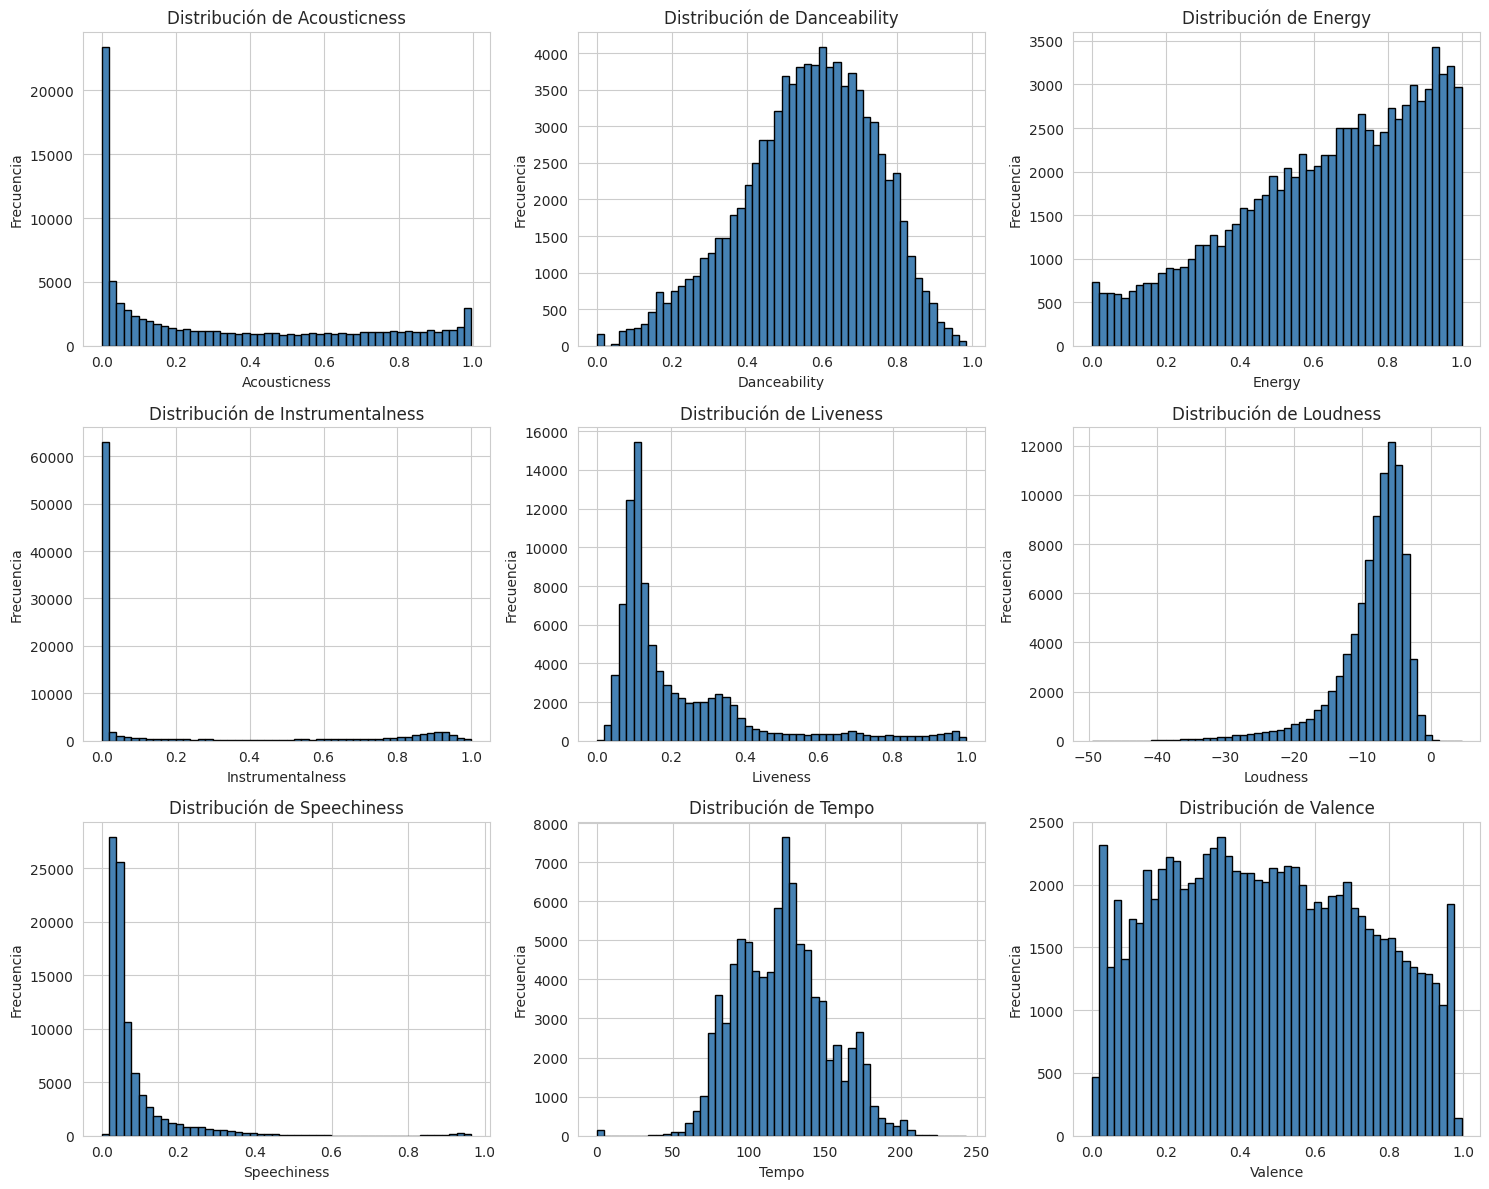

In [195]:
# Gráficos de distribución de características de audio
audio_features = ['acousticness', 'danceability', 'energy', 'instrumentalness', 
                   'liveness', 'loudness', 'speechiness', 'tempo', 'valence']

available_features = [col for col in audio_features if col in df.columns]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, feature in enumerate(available_features[:9]):
    axes[idx].hist(df[feature].dropna(), bins=50, color='steelblue', edgecolor='black')
    axes[idx].set_title(f'Distribución de {feature.title()}')
    axes[idx].set_xlabel(feature.title())
    axes[idx].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Interpretación



## 2.2. Análisis de popularidad

Examinemos cómo se distribuye la popularidad de las pistas en el dataset.

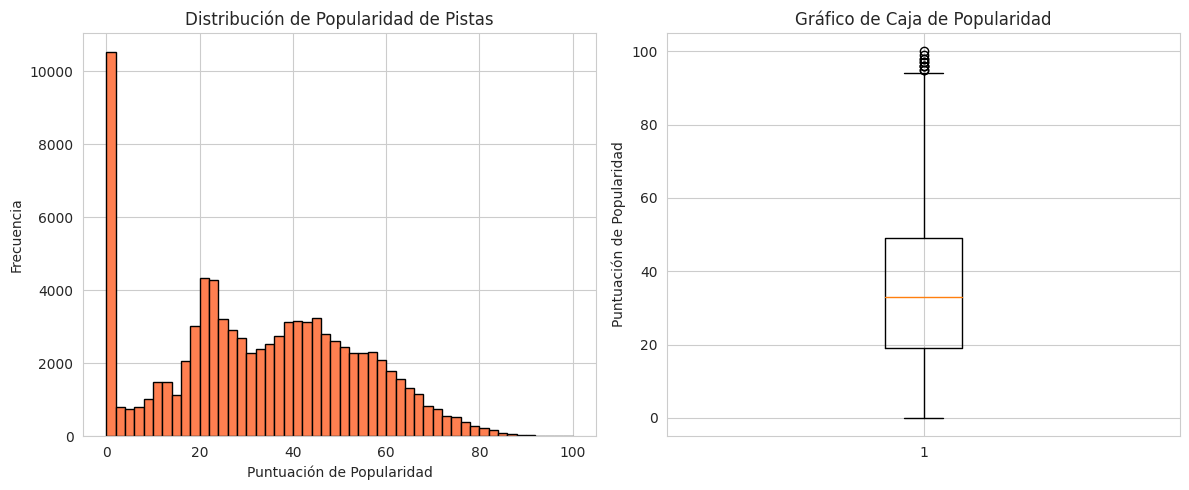


Estadísticas de Popularidad:
count    89740.000000
mean        33.198808
std         20.580640
min          0.000000
25%         19.000000
50%         33.000000
75%         49.000000
max        100.000000
Name: popularity, dtype: float64


In [196]:
if 'popularity' in df.columns:
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.hist(df['popularity'].dropna(), bins=50, color='coral', edgecolor='black')
    plt.title('Distribución de Popularidad de Pistas')
    plt.xlabel('Puntuación de Popularidad')
    plt.ylabel('Frecuencia')
    
    plt.subplot(1, 2, 2)
    plt.boxplot(df['popularity'].dropna())
    plt.title('Gráfico de Caja de Popularidad')
    plt.ylabel('Puntuación de Popularidad')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nEstadísticas de Popularidad:")
    print(df['popularity'].describe())

### Interpretación



## 2.3. Análisis de popularidad por género

Examinamos cómo varía la popularidad media entre los distintos géneros musicales del dataset. Esto permite identificar qué géneros tienden a generar canciones más populares en Spotify.

### Top géneros

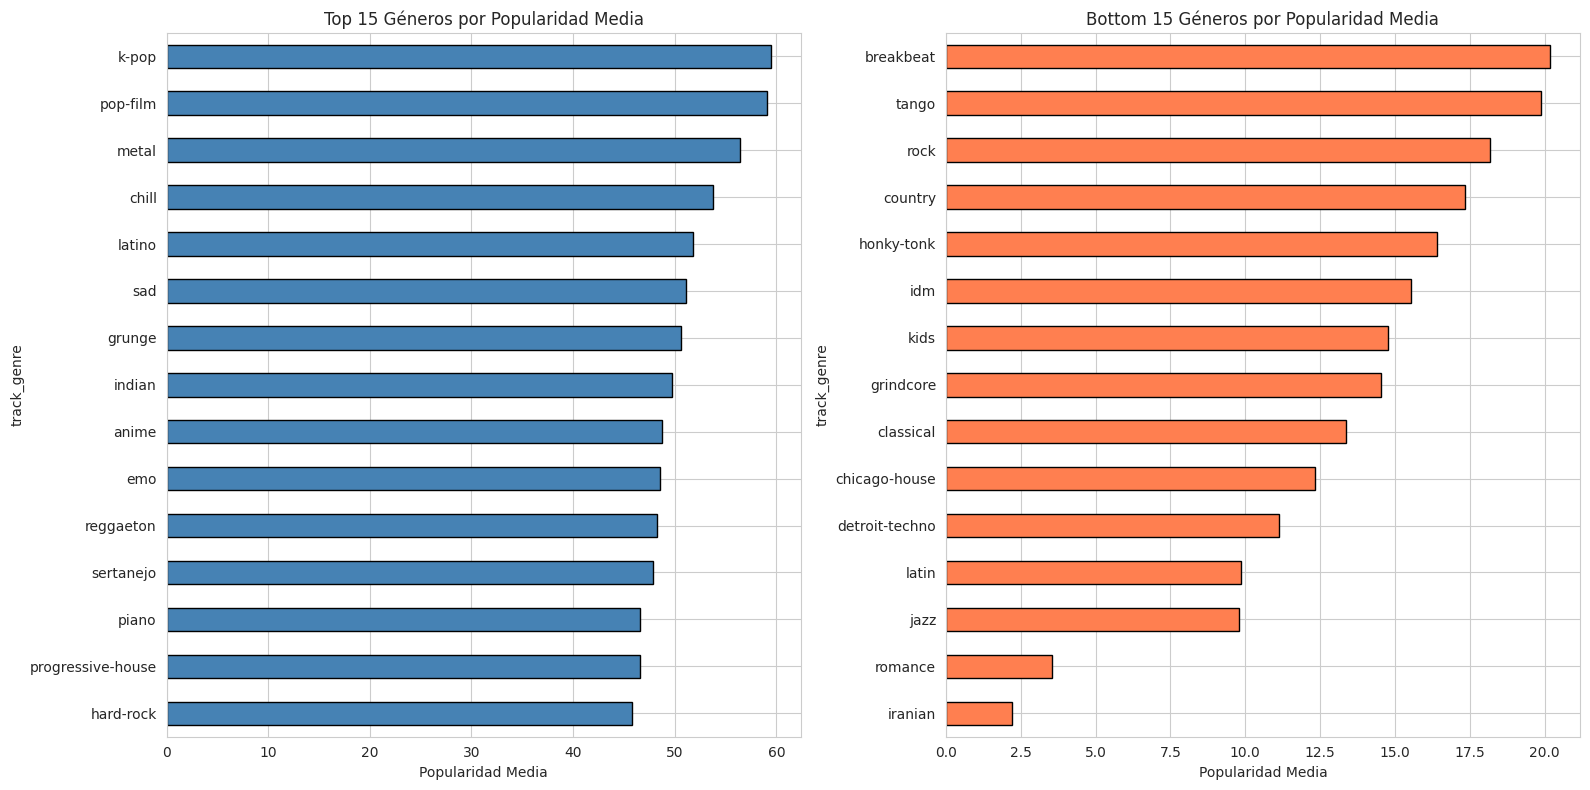

In [197]:
# Popularidad media por género
genre_popularity = df.groupby('track_genre')['popularity'].agg(['mean', 'median', 'count'])
genre_popularity.columns = ['media', 'mediana', 'cantidad']
genre_popularity = genre_popularity.sort_values('media', ascending=False)

# Top 15 géneros más populares
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 15
genre_popularity['media'].head(15).plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('Top 15 Géneros por Popularidad Media')
axes[0].set_xlabel('Popularidad Media')
axes[0].invert_yaxis()

# Bottom 15
genre_popularity['media'].tail(15).plot(
    kind='barh', ax=axes[1], color='coral', edgecolor='black'
)
axes[1].set_title('Bottom 15 Géneros por Popularidad Media')
axes[1].set_xlabel('Popularidad Media')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### Distribución por género

/tmp/ipykernel_22950/442177367.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top, x='track_genre', y='popularity', order=order, palette='viridis')


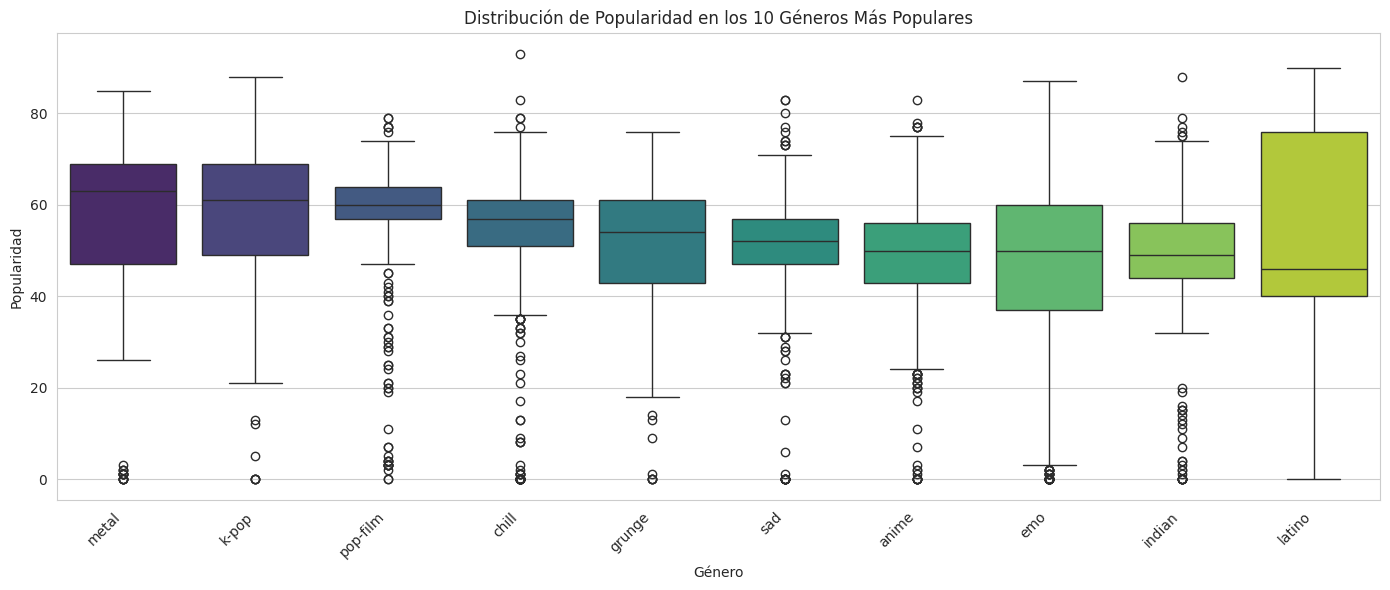

In [198]:
# Boxplot de popularidad para los 10 géneros más populares
top_genres = genre_popularity.head(10).index.tolist()

plt.figure(figsize=(14, 6))
df_top = df[df['track_genre'].isin(top_genres)]
order = df_top.groupby('track_genre')['popularity'].median().sort_values(ascending=False).index

sns.boxplot(data=df_top, x='track_genre', y='popularity', order=order, palette='viridis')
plt.title('Distribución de Popularidad en los 10 Géneros Más Populares')
plt.xlabel('Género')
plt.ylabel('Popularidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Características de audio por género

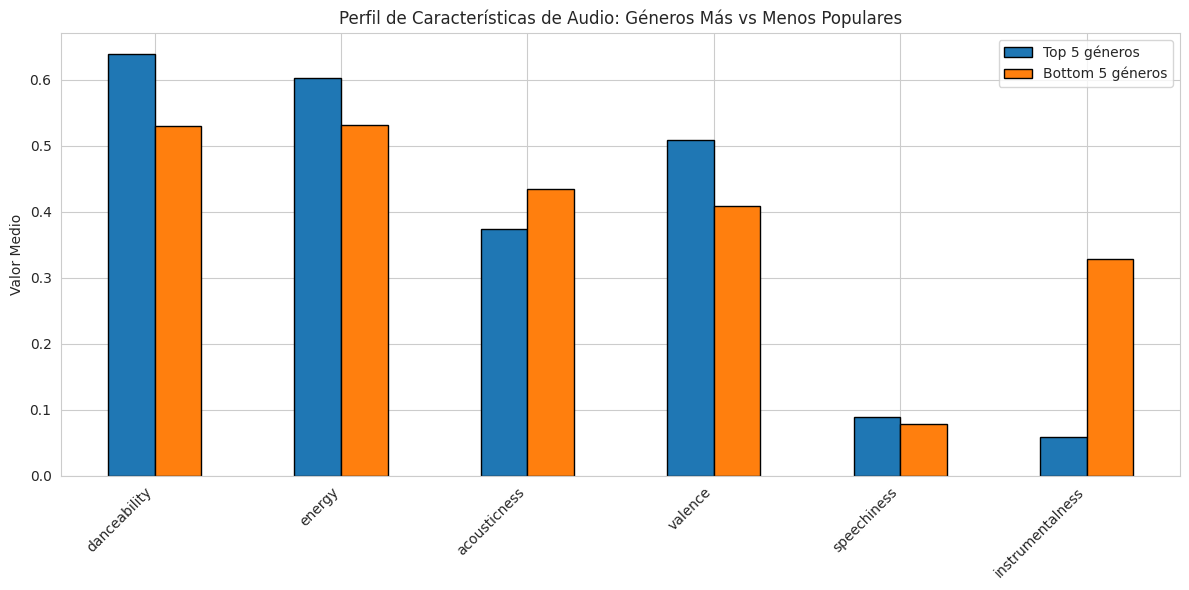

                  Top 5 géneros  Bottom 5 géneros
danceability              0.639             0.529
energy                    0.603             0.532
acousticness              0.373             0.434
valence                   0.509             0.408
speechiness               0.089             0.078
instrumentalness          0.059             0.328


In [199]:
# Perfil de características de audio de los 5 géneros más y menos populares
top_5 = genre_popularity.head(5).index.tolist()
bottom_5 = genre_popularity.tail(5).index.tolist()

audio_features_comparision = ['danceability', 'energy', 'acousticness', 'valence', 'speechiness', 'instrumentalness']

profile_top = df[df['track_genre'].isin(top_5)][audio_features_comparision].mean()
profile_bottom = df[df['track_genre'].isin(bottom_5)][audio_features_comparision].mean()

comparison = pd.DataFrame({
    'Top 5 géneros': profile_top,
    'Bottom 5 géneros': profile_bottom
})

comparison.plot(kind='bar', figsize=(12, 6), edgecolor='black')
plt.title('Perfil de Características de Audio: Géneros Más vs Menos Populares')
plt.ylabel('Valor Medio')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(comparison.round(3))

### Interpretación

- Existe una variabilidad significativa en la popularidad media entre géneros, lo que sugiere que el género es un factor relevante en la popularidad de una pista.
- Los géneros más populares tienden a presentar mayor danceability y energy, mientras que los menos populares muestran mayor instrumentalness y acousticness.
- La dispersión dentro de cada género (visible en los boxplots) indica que el género por sí solo no determina la popularidad, pero sí establece un rango base.

## 2.4. Detección de outliers en características de audio

Identificamos valores atípicos en las características de audio que podrían afectar el rendimiento de los modelos.

### Visualización

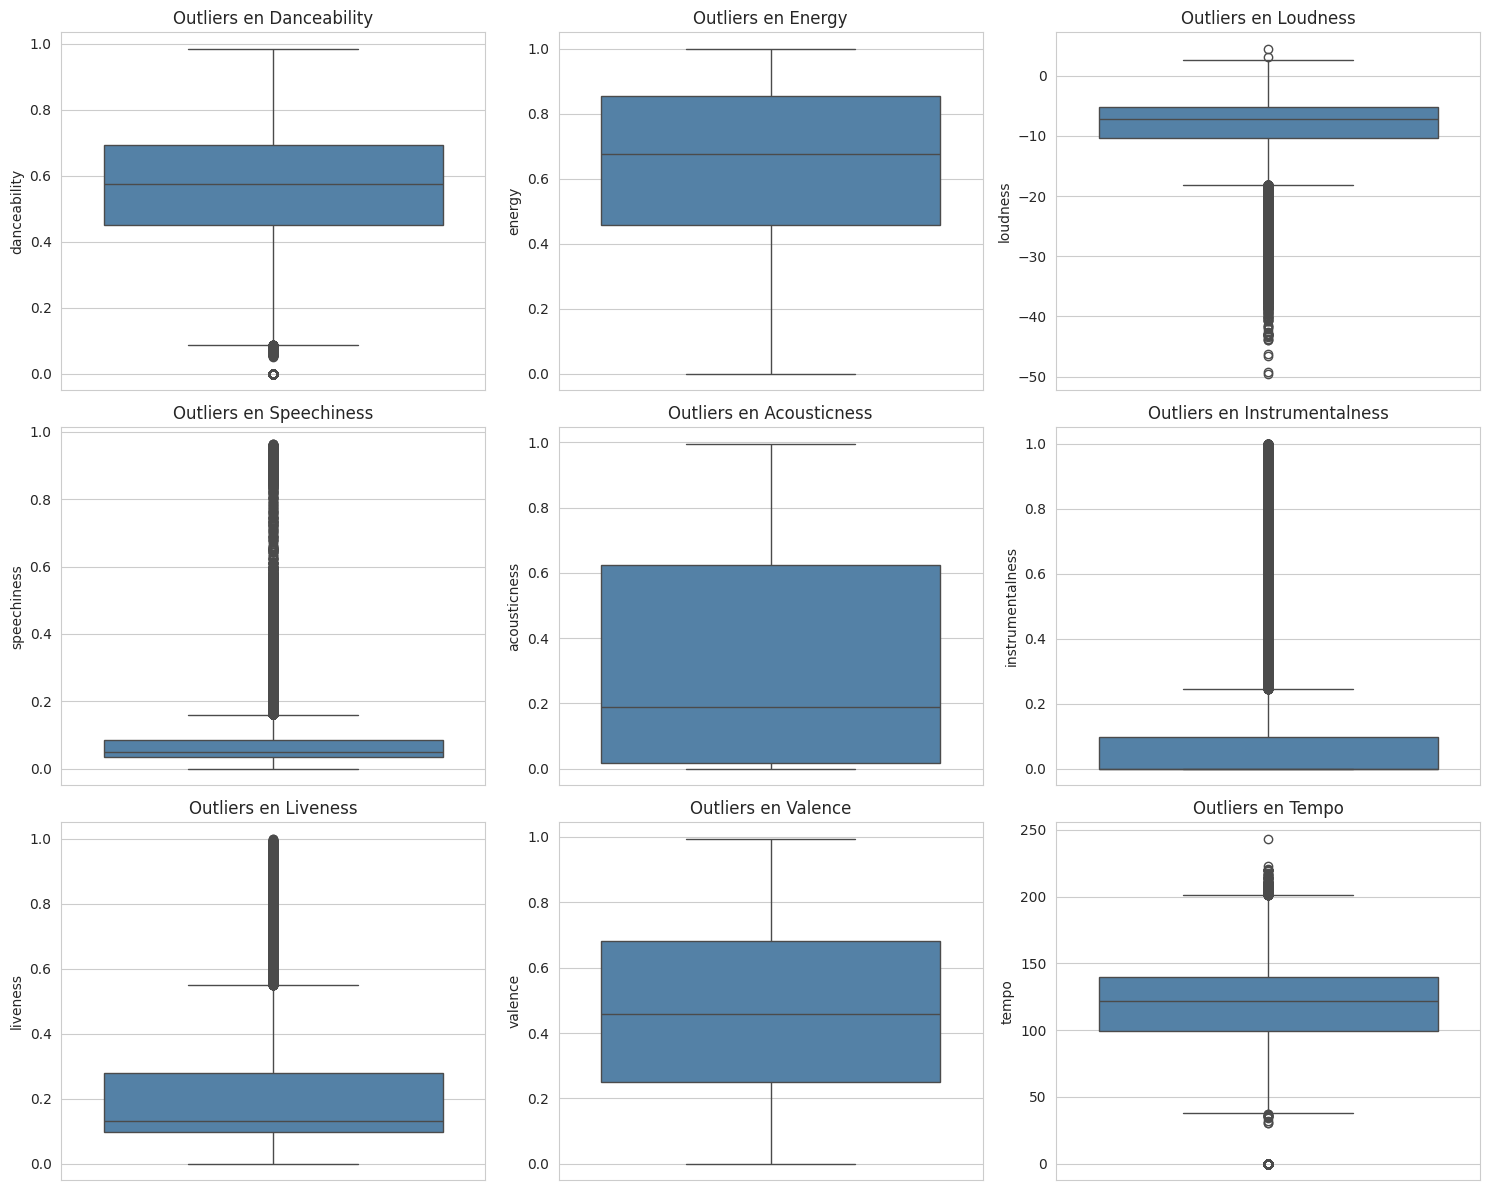

In [200]:
audio_features_full = ['danceability', 'energy', 'loudness', 'speechiness', 
                       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

available = [col for col in audio_features_full if col in df.columns]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, feature in enumerate(available[:9]):
    sns.boxplot(data=df, y=feature, ax=axes[idx], color='steelblue')
    axes[idx].set_title(f'Outliers en {feature.title()}')

plt.tight_layout()
plt.show()

### Cuantificación

In [201]:
# Contar outliers usando método IQR
outlier_summary = []

for feature in available:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[feature] < lower) | (df[feature] > upper)).sum()
    pct = (n_outliers / len(df)) * 100
    outlier_summary.append({
        'feature': feature,
        'outliers': n_outliers,
        'porcentaje': round(pct, 2),
        'límite_inferior': round(lower, 3),
        'límite_superior': round(upper, 3)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('porcentaje', ascending=False)
print(outlier_df.to_string(index=False))

         feature  outliers  porcentaje  límite_inferior  límite_superior
instrumentalness     19613       21.86           -0.146            0.244
     speechiness     10644       11.86           -0.039            0.161
        liveness      6981        7.78           -0.173            0.550
        loudness      5026        5.60          -18.144            2.713
           tempo       514        0.57           38.041          201.298
    danceability       474        0.53            0.087            1.055
          energy         0        0.00           -0.137            1.447
    acousticness         0        0.00           -0.895            1.537
         valence         0        0.00           -0.401            1.332


### Interpretación

- Variables como `instrumentalness`, `speechiness` y `liveness` presentan distribuciones muy sesgadas, lo que genera un alto número de outliers según el método IQR.
- Estos outliers no son necesariamente errores; representan canciones con características extremas (por ejemplo, pistas puramente instrumentales o spoken word).
- Para los modelos basados en árboles (Random Forest, XGBoost) no es necesario eliminarlos. Para modelos lineales o basados en distancias, se recomienda considerar transformaciones logarítmicas o winsorización.

## 2.5. Correlaciones entre características de audio

Examinamos cómo diferentes características de audio se relacionan entre sí y con la popularidad.

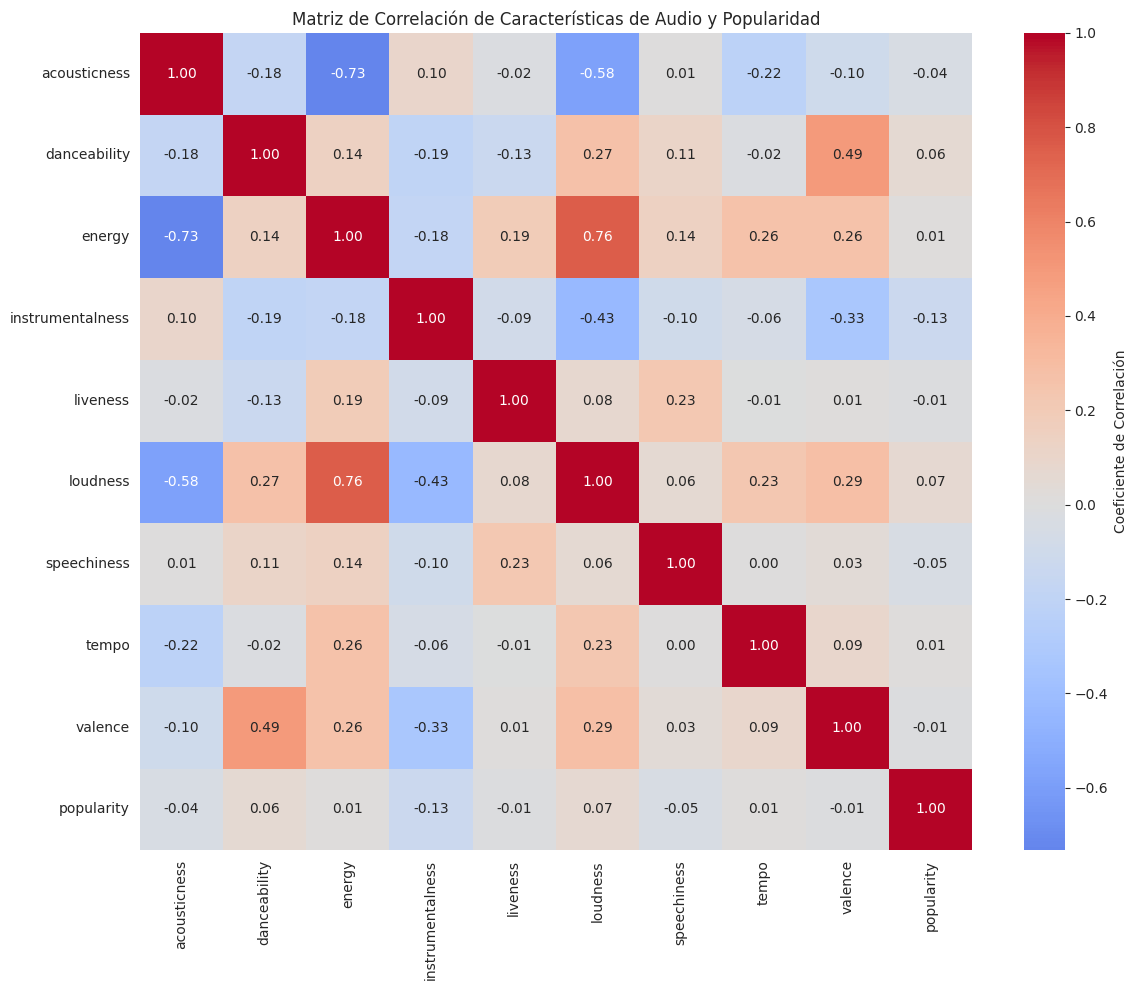

In [202]:
# Seleccionar características de audio para análisis de correlación
correlation_cols = [col for col in available_features if col in df.columns]
if 'popularity' in df.columns:
    correlation_cols.append('popularity')

# Calcular matriz de correlación
if len(correlation_cols) > 1:
    correlation_matrix = df[correlation_cols].corr()
    
    # Gráfico de mapa de calor de correlación
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                cbar_kws={'label': 'Coeficiente de Correlación'})
    plt.title('Matriz de Correlación de Características de Audio y Popularidad')
    plt.tight_layout()
    plt.show()

### Interpretación



## 2.6. Relación entre características de audio y popularidad

Analizamos cómo características de audio individuales se relacionan con la popularidad de las pistas.

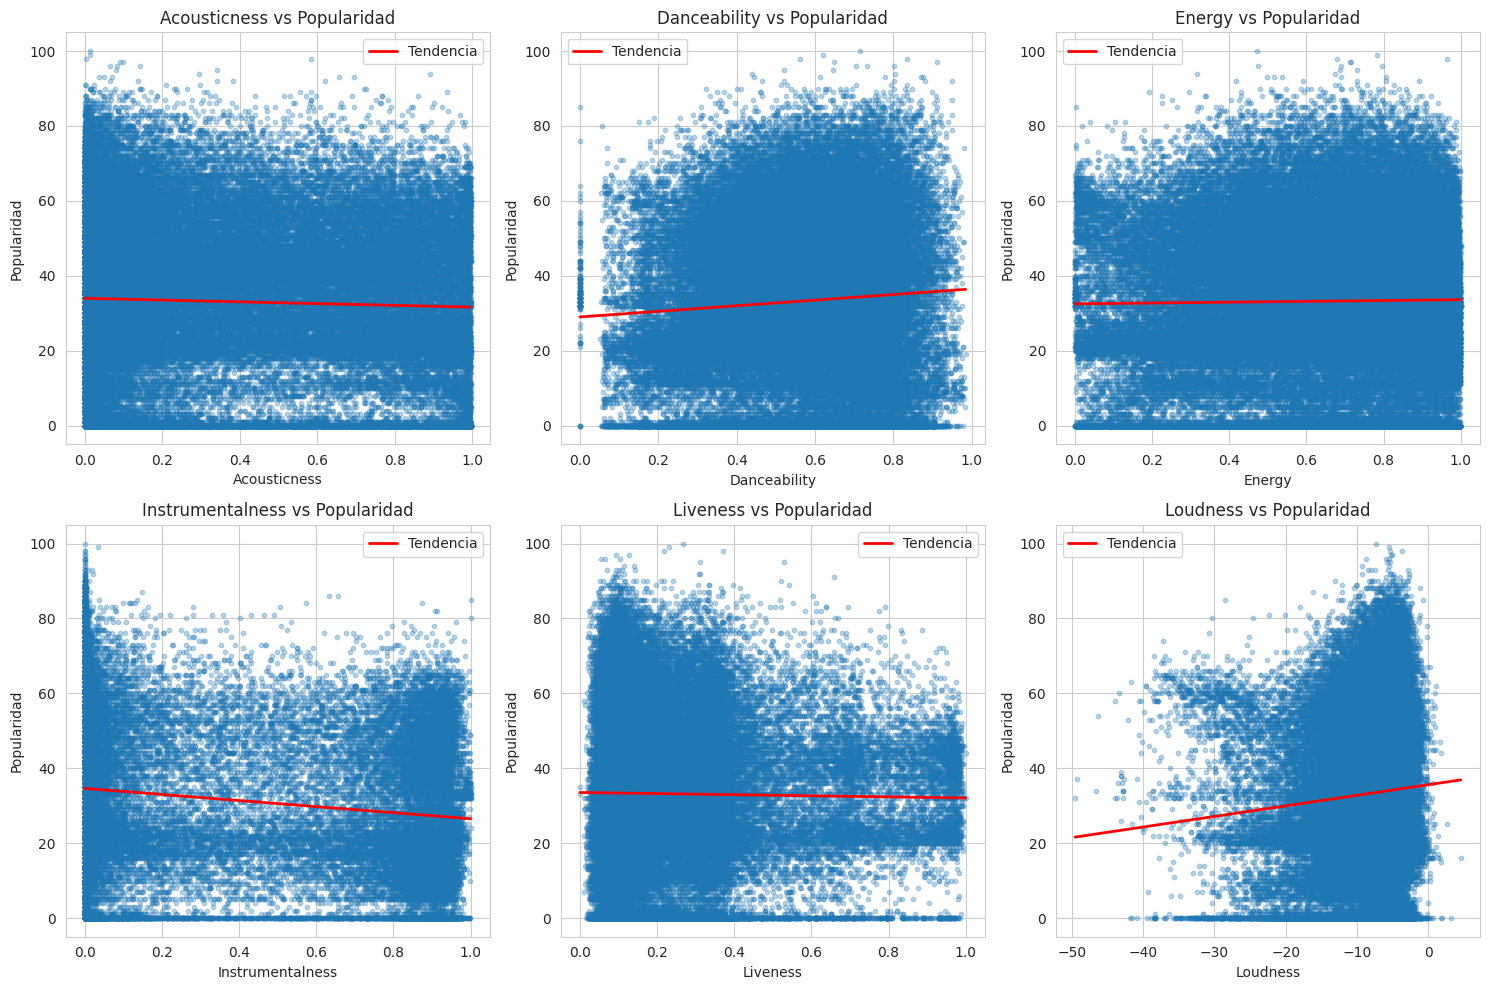

In [203]:
if 'popularity' in df.columns and len(available_features) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()
    
    features_to_plot = available_features[:6]
    
    for idx, feature in enumerate(features_to_plot):
        axes[idx].scatter(df[feature], df['popularity'], alpha=0.3, s=10)
        axes[idx].set_xlabel(feature.title())
        axes[idx].set_ylabel('Popularidad')
        axes[idx].set_title(f'{feature.title()} vs Popularidad')
        
        # Agregar línea de tendencia
        mask = df[feature].notna() & df['popularity'].notna()
        z = np.polyfit(df.loc[mask, feature], df.loc[mask, 'popularity'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(df[feature].min(), df[feature].max(), 100)
        axes[idx].plot(x_line, p(x_line), 'r-', linewidth=2, label='Tendencia')
        axes[idx].legend()
    
    plt.tight_layout()
    plt.show()

### Interpretación



---

# 3. Preparación de datos

## 3.1. Selección y transformación de variables

En esta fase se seleccionan y transforman las variables para su uso en modelos de machine learning.

Se eliminan variables que no aportan valor predictivo o que no pueden ser utilizadas directamente por los modelos, como identificadores o variables de texto libre.

Además, se construye un dataset específico para modelado (`df_model`), manteniendo el dataset original para el análisis exploratorio.

In [204]:
df_model = df.copy()

cols_to_drop = ["track_name", "artists", "album_name", "track_id", "track_genre"]

df_model = df_model.drop(columns=[col for col in cols_to_drop if col in df_model.columns])

## 3.2 Separación de variables

En esta fase se separa la variable objetivo (`popularity`) del resto de variables predictoras.

In [205]:
X = df_model.drop(columns=["popularity"])
y = df_model["popularity"]

## 3.3. División entre train y test

Se divide el dataset en conjunto de entrenamiento y test para evaluar correctamente los modelos.

In [206]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 3.4. Escalado de variables

Algunos modelos requieren que las variables estén escaladas.

In [207]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3.5. Preparación para clasificación

Además del problema de regresión, se define una variable binaria para clasificar canciones como populares o no.  

Antes de definir la variable `hit`, vamos a hacer un pequeño análisis de percentiles para justificar el umbral.

In [208]:
# Análisis de percentiles para justificar el umbral
print("Percentiles de popularidad:")
for p in [50, 70, 75, 80, 90, 95]:
    print(f"  Percentil {p}: {df_model['popularity'].quantile(p/100):.0f}")

Percentiles de popularidad:
  Percentil 50: 33
  Percentil 70: 45
  Percentil 75: 49
  Percentil 80: 52
  Percentil 90: 60
  Percentil 95: 67


Basándonos en la distribución de percentiles, se define el umbral de popularidad > 70 para clasificar una canción como "hit". Este valor se sitúa aproximadamente en el percentil superior del dataset, representando las canciones con mayor éxito relativo.

In [209]:
df_model["hit"] = (df_model["popularity"] > 70).astype(int)

In [210]:
X_class = df_model.drop(columns=["popularity", "hit"])
y_class = df_model["hit"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

print(f"Variables de clasificación: {X_class.columns.tolist()}")
print(f"Distribución de clases:\n{y_class.value_counts(normalize=True).round(3)}")

Variables de clasificación: ['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
Distribución de clases:
hit
0    0.97
1    0.03
Name: proportion, dtype: float64


## 3.6. Resumen

En esta fase:
- Se ha definido la variable objetivo  
- Se han separado los datos en entrenamiento y test  
- Se han preparado los datos para regresión y clasificación  
- Se han escalado las variables para modelos que lo requieren  

El dataset queda listo para el entrenamiento de modelos.